# Read data

In [1]:
import pandas as pd

df = pd.read_csv('../../input/titanic_train.csv')

# Check Dimension, shape, types (training+validation)

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Training Dataset shape is: ", df.shape)

Training Dataset shape is:  (891, 12)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Check for Duplicate Rows

In [5]:
df['Age'].duplicated()

0      False
1      False
2      False
3      False
4       True
       ...  
886     True
887     True
888     True
889     True
890     True
Name: Age, Length: 891, dtype: bool

In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

# Identify Column Data Types

In [7]:
cat_col = [col for col in df.columns if df[col].dtype in ('object', 'str')]
num_col = [col for col in df.columns if df[col].dtype not in ('object', 'str')]

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


# Count Unique Values in the Categorical Columns

In [8]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

# Calculate Missing Values as Percentage

- df.isnull(): Detects missing values, returning boolean DataFrame.
- Sum missing across columns, normalize by total rows and multiply by 100.

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.shape

(891, 12)

In [11]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

# Drop Irrelevant or Data-Heavy Missing Columns

- df.drop(columns=[]): Drops specified columns from the DataFrame.
- df.dropna(subset=[]): Removes rows where specified columns have missing values.
- fillna(): Fills missing values with specified value (e.g., mean).

In [12]:
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])

df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [13]:
print('Nr. of items - Before:', df1.shape[0])
df1 = df1.dropna(subset=['Embarked'])
print('Nr. of items - After:', df1.shape[0])

Nr. of items - Before: 891
Nr. of items - After: 889


In [14]:
print('Null values - Before:', df['Age'].isnull().sum())
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())
print('Null values - After:', df1['Age'].isnull().sum())

Null values - Before: 177
Null values - After: 0


# Detect Outliers with Box Plot

- matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.

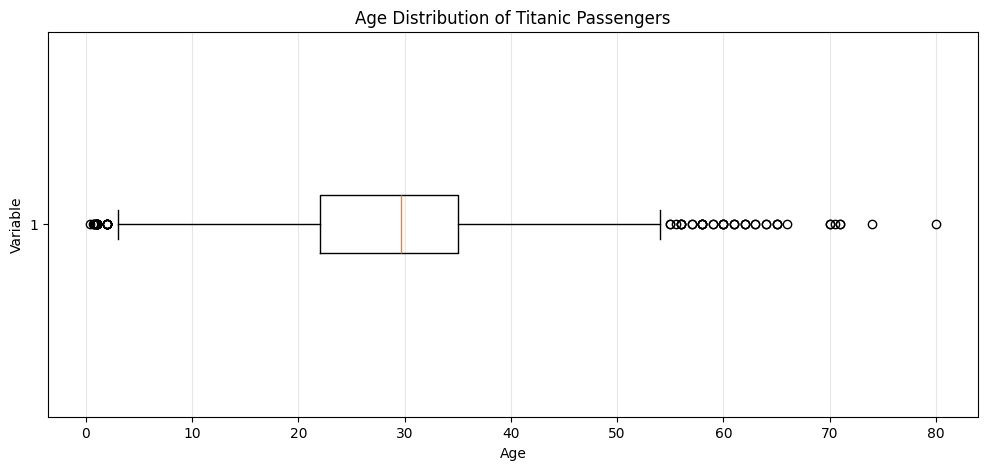

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Age Distribution of Titanic Passengers')
plt.grid(axis='x', alpha=0.3)

Median (line inside box) = 50th percentile – half of passengers are younger, half older

Box (Q1 to Q3) = Interquartile Range (IQR) – middle 50% of data.
If Q1=22 and Q3=35, then half of all passengers were between 22–35 years old.

Whiskers = Range of "normal" values (up to 1.5×IQR from Q1/Q3)

Individual points beyond whiskers = Outliers – unusually young or old passengers.
May include infants (<1 year) or elderly passengers (>70). Worth investigating!

In [16]:
df1['Age'].describe()

count    889.000000
mean      29.642093
std       12.968346
min        0.420000
25%       22.000000
50%       29.642093
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [17]:
Q1 = df1['Age'].quantile(0.25)
Q3 = df1['Age'].quantile(0.75)
IQR = Q3 - Q1

# Q1 (First Quartile / 25th Percentile), The value below which 25% of the data falls.
# IQR (Interquartile Range)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df1[(df1['Age'] < lower_bound) | (df1['Age'] > upper_bound)]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of age outliers: {len(outliers)}")
print(outliers[['PassengerId', 'Age', 'Pclass', 'Survived']].head())

Q1: 22.00, Q3: 35.00, IQR: 13.00
Outlier bounds: [2.50, 54.50]
Number of age outliers: 65
    PassengerId   Age  Pclass  Survived
7             8   2.0       3         0
11           12  58.0       1         1
15           16  55.0       2         1
16           17   2.0       3         0
33           34  66.0       2         0


# Calculate Outlier Boundaries and Remove Them

You can calculate with mean or how we did before

In [18]:
df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

df2.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [19]:
mean = df2['Age'].mean()
std = df2['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

Lower Bound : 8.490463217391493
Upper Bound : 49.222280489655525


# Impute Missing Data Again if Any

In [20]:
df2 = df2.fillna(df2['Age'].mean())
df2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

# Data validation and verification

Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge.

In [21]:
X = df2[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
y = df2['Survived']

In [22]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [23]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Data formatting

https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/

### Min-Max Scaling

Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaler_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

X[scaler_cols] = scaler.fit_transform(X[scaler_cols])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.372549,0.125,0.0,0.014151,S
1,0.0,female,0.686275,0.125,0.0,0.139136,C
2,1.0,female,0.450980,0.000,0.0,0.015469,S
3,0.0,female,0.627451,0.125,0.0,0.103644,S
4,1.0,male,0.627451,0.000,0.0,0.015713,S


###  Standardization (Z-score scaling)

Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.